✅ Datos cargados exitosamente.


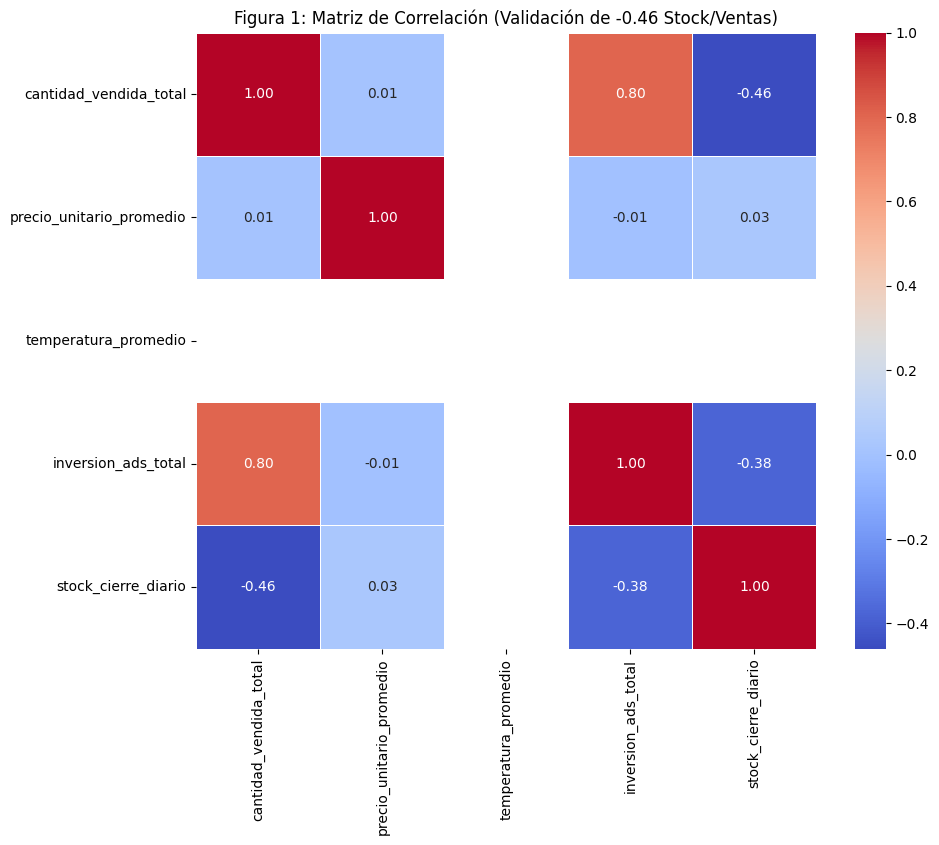

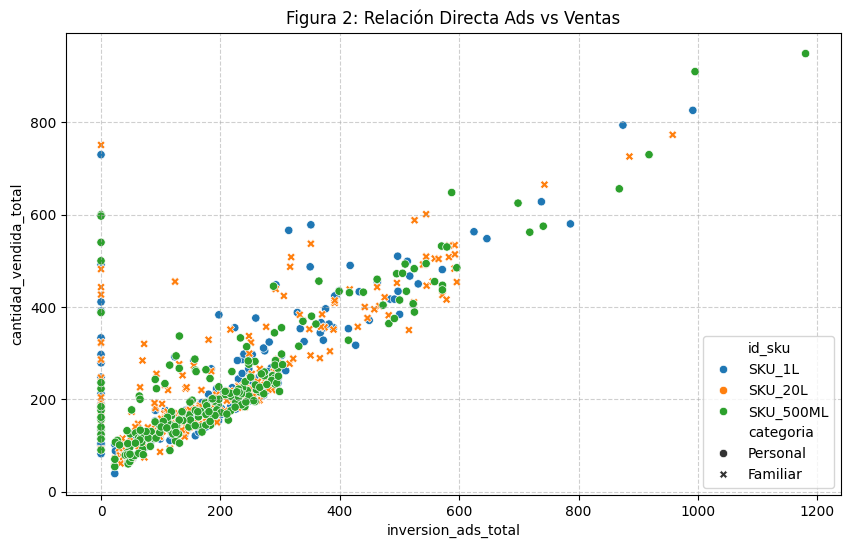

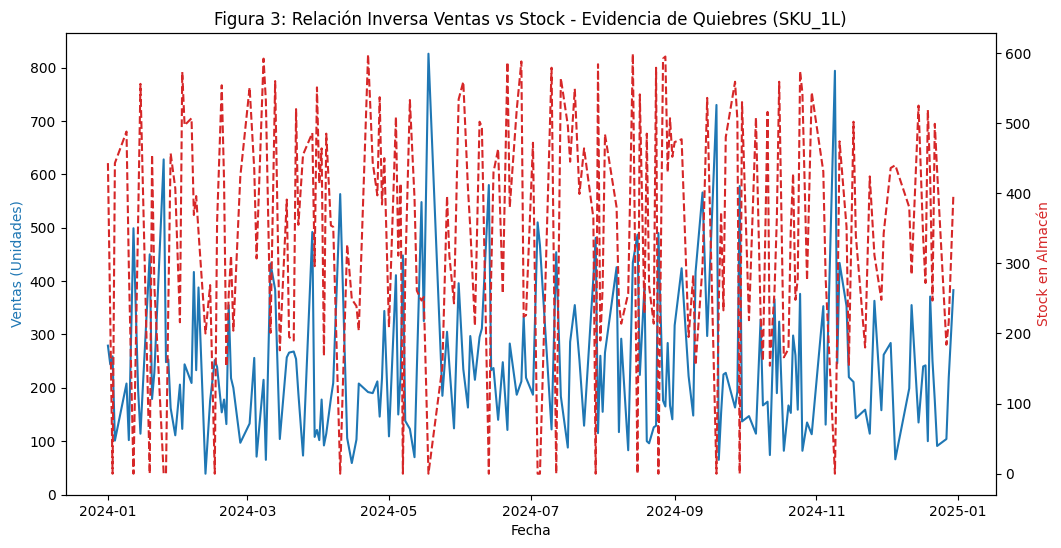


--- RESUMEN ESTADISTICO ---
✅ Correlación Stock/Ventas: -0.4599
✅ Correlación Publicidad/Ventas: 0.8020
✅ Promedio de Ventas por Producto:
nombre_producto
Bidon_20L        241.970213
Botella_1L       242.425743
Botella_500ml    237.226244
Name: cantidad_vendida_total, dtype: float64


In [9]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# 1. Cargar el Dataset Maestro desde el archivo exportado
df_gold = pd.read_csv('gold_ml_feature_set.csv')
df_gold['fecha'] = pd.to_datetime(df_gold['fecha'])

print("✅ Datos cargados exitosamente.")

# 2. Ingeniería de Atributos (Feature Engineering)
# Ordenamos por producto y fecha para que los "saltos" de días sean correctos
df_gold = df_gold.sort_values(['id_sku', 'fecha'])

# Ciclo Semanal: Extraemos el número de día (0=Lunes, 6=Domingo)
df_gold['dia_semana'] = df_gold['fecha'].dt.dayofweek

# Lag 1: Desplaza la inversión un día hacia adelante para ver el efecto de ayer en las ventas de hoy
df_gold['ads_lag1'] = df_gold.groupby('id_sku')['inversion_ads_total'].shift(1)

# Lag 2: Desplaza la inversión dos días para ver el efecto de anteayer
df_gold['ads_lag2'] = df_gold.groupby('id_sku')['inversion_ads_total'].shift(2)

# 3. Matriz de Correlación de Pearson
cols_analisis = ['cantidad_vendida_total', 'precio_unitario_promedio',
                 'temperatura_promedio', 'inversion_ads_total', 'stock_cierre_diario']
corr_matrix = df_gold[cols_analisis].corr()

# Visualización 1: Heatmap de Correlación (Prueba Matemática)
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Figura 1: Matriz de Correlación (Validación de -0.46 Stock/Ventas)')
plt.show()

# Visualización 2: Ventas vs Inversión en Publicidad
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_gold, x='inversion_ads_total', y='cantidad_vendida_total', hue='id_sku', style='categoria')
plt.title('Figura 2: Relación Directa Ads vs Ventas')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

# Visualización 3: Gráfico de Series de Tiempo (Prueba Visual de Agotamiento de Stock)
# Seleccionamos un producto para ver el detalle claro
sku_ejemplo = df_gold['id_sku'].unique()[0]
df_sku = df_gold[df_gold['id_sku'] == sku_ejemplo]

fig, ax1 = plt.subplots(figsize=(12, 6))

ax1.set_xlabel('Fecha')
ax1.set_ylabel('Ventas (Unidades)', color='tab:blue')
ax1.plot(df_sku['fecha'], df_sku['cantidad_vendida_total'], color='tab:blue', label='Ventas')

ax2 = ax1.twinx()
ax2.set_ylabel('Stock en Almacén', color='tab:red')
ax2.plot(df_sku['fecha'], df_sku['stock_cierre_diario'], color='tab:red', linestyle='--', label='Stock')

plt.title(f'Figura 3: Relación Inversa Ventas vs Stock - Evidencia de Quiebres ({sku_ejemplo})')
plt.show()

# 4. Resumen Estadístico para el Informe
print("\n--- RESUMEN ESTADISTICO ---")
print(f"✅ Correlación Stock/Ventas: {corr_matrix.loc['stock_cierre_diario', 'cantidad_vendida_total']:.4f}")
print(f"✅ Correlación Publicidad/Ventas: {corr_matrix.loc['inversion_ads_total', 'cantidad_vendida_total']:.4f}")
print("✅ Promedio de Ventas por Producto:")
print(df_gold.groupby('nombre_producto')['cantidad_vendida_total'].mean())